# Cheap-and-Upsell, or High-Margin? A Pricing Strategy Study

**Author:** Namık Akman  
**Question:** RavenStack runs three plan tiers — Basic, Pro, Enterprise — with a ~10× price gap between the cheapest and most expensive. Should the company **lead with the cheap plan and rely on upsells**, or **target high-margin customers from day one**?

This is the central commercial question of any subscription business with a multi-tier offer. The data has 500 customers, 5,000 subscription records, 24 months of history, and enough plan-change activity to give a clean answer.

## What the answer depends on

1. **Lifetime revenue (LTV) per landing plan.** A Basic customer pays less monthly — but how much do they pay over their full lifetime, including upgrades?
2. **The upgrade conversion rate.** Cheap-and-upsell only works if Basic customers actually upgrade. Do they?
3. **Acquisition source × plan.** Different channels deliver different customers. Where are the high-LTV customers really coming from?
4. **Contract structure.** Does annual billing lock customers in long enough to justify the discount, or is it neutral?

## How LTV is computed here

Each account's lifetime revenue = sum over their entire subscription history of `MRR × duration_at_that_plan`. When a customer changes plan, the previous record's effective end-date is the start of the next record. For active customers, the effective end is the observation cutoff (2024-12-31). For churned customers, it is their last recorded churn date. The result is the actual cumulative revenue each customer has generated.

## 1. Setup and LTV construction

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path(r'C:\Users\Lenovo\OneDrive\Creative\Churn Study\data')

BRAND_BLUE, BRAND_GREEN, BRAND_ORANGE = '#2F9BFF', '#19C37D', '#FF6500'
BG_DARK, FG_LIGHT = '#0F1419', '#E6EDF3'
plt.rcParams.update({
    'figure.facecolor': BG_DARK, 'axes.facecolor': BG_DARK, 'savefig.facecolor': BG_DARK,
    'axes.edgecolor': FG_LIGHT, 'axes.labelcolor': FG_LIGHT,
    'xtick.color': FG_LIGHT, 'ytick.color': FG_LIGHT, 'text.color': FG_LIGHT,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

accounts = pd.read_csv(DATA / 'ravenstack_accounts.csv', parse_dates=['signup_date'])
subs = pd.read_csv(DATA / 'ravenstack_subscriptions.csv', parse_dates=['start_date','end_date'])
churn_events = pd.read_csv(DATA / 'ravenstack_churn_events.csv', parse_dates=['churn_date'])
obs_end = pd.Timestamp('2024-12-31')

real_churns = churn_events[~churn_events['is_reactivation'].astype(bool)]
last_churn = real_churns.groupby('account_id')['churn_date'].max().rename('last_churn_date')
acc = accounts.merge(last_churn, on='account_id', how='left')
acc['exit_date'] = pd.to_datetime(np.where(acc['churn_flag'], acc['last_churn_date'].fillna(obs_end), obs_end))

# Reconstruct subscription durations
subs = subs.sort_values(['account_id','start_date']).reset_index(drop=True)
subs = subs.merge(acc[['account_id','exit_date']], on='account_id', how='left')
subs['next_start'] = subs.groupby('account_id')['start_date'].shift(-1)
subs['effective_end'] = subs[['end_date','next_start','exit_date']].min(axis=1)
subs['effective_end'] = subs[['effective_end','exit_date']].min(axis=1)
subs['duration_days'] = (subs['effective_end'] - subs['start_date']).dt.days.clip(lower=0)
subs['duration_months'] = subs['duration_days'] / 30
subs['revenue'] = subs['mrr_amount'] * subs['duration_months']

plan_order = ['Basic','Pro','Enterprise']
plan_rank = {p:i for i,p in enumerate(plan_order)}

def first_plan(g):  return g.sort_values('start_date').iloc[0]['plan_tier']
def highest_plan(g): return max(g['plan_tier'], key=lambda x: plan_rank[x])

per_acc = (subs.groupby('account_id').agg(
    total_revenue=('revenue','sum'),
    n_subscriptions=('subscription_id','count'),
    n_upgrades=('upgrade_flag','sum'),
    tenure_months=('duration_months','sum'),
).reset_index())
per_acc['landing_plan'] = subs.groupby('account_id').apply(first_plan, include_groups=False).reset_index(drop=True).values
per_acc['highest_plan'] = subs.groupby('account_id').apply(highest_plan, include_groups=False).reset_index(drop=True).values
per_acc = per_acc.merge(accounts[['account_id','referral_source','industry','country','churn_flag']], on='account_id', how='left')
per_acc['billing'] = (subs.groupby('account_id')['billing_frequency']
                     .agg(lambda s: s.mode().iloc[0]).reset_index(drop=True).values)
per_acc['upgraded'] = per_acc['n_upgrades'] > 0

print(f'Accounts: {len(per_acc)} | sub-records: {len(subs)}')
print(f'Median LTV: ${per_acc["total_revenue"].median():,.0f}  Mean LTV: ${per_acc["total_revenue"].mean():,.0f}')

Accounts: 500 | sub-records: 5000
Median LTV: $13,204  Mean LTV: $21,315


## 2. The first surprise: LTV is nearly equal across landing plans

Before splitting customers by *what they did*, look at what they *started with*. The naive expectation is that Enterprise landings generate much higher LTV than Basic landings — after all, they pay 10× more per month.

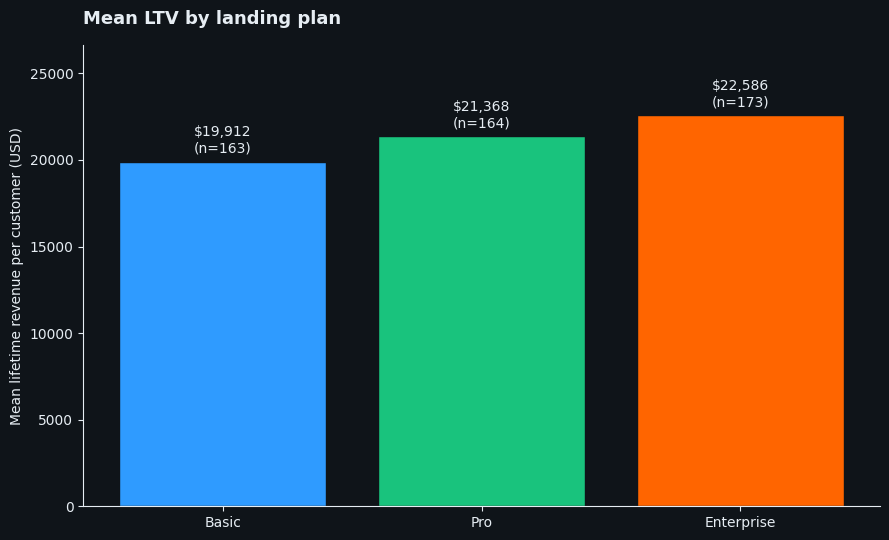

,n,mean_ltv,median_ltv,avg_tenure_mo,churn_rate,upgrade_share
landing_plan,,,,,,
Basic,163,"$19,912","$11,654",9.6,22.1%,60.7%
Pro,164,"$21,368","$14,561",9.8,19.5%,61.6%
Enterprise,173,"$22,586","$14,260",8.7,24.3%,61.8%


In [2]:
ltv_by_land = per_acc.groupby('landing_plan').agg(
    n=('account_id','count'),
    mean_ltv=('total_revenue','mean'),
    median_ltv=('total_revenue','median'),
    avg_tenure_mo=('tenure_months','mean'),
    churn_rate=('churn_flag','mean'),
    upgrade_share=('upgraded','mean'),
).reindex(plan_order)

fig, ax = plt.subplots(figsize=(9, 5.5))
vals = ltv_by_land['mean_ltv'].values
bars = ax.bar(plan_order, vals, color=[BRAND_BLUE, BRAND_GREEN, BRAND_ORANGE], edgecolor=BG_DARK)
for bar, v, n in zip(bars, vals, ltv_by_land['n'].values):
    ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.015,
            f'${v:,.0f}\n(n={n})', ha='center', va='bottom', color=FG_LIGHT, fontsize=10)
ax.set_ylabel('Mean lifetime revenue per customer (USD)')
ax.set_title('Mean LTV by landing plan', loc='left', pad=15)
ax.set_ylim(0, max(vals) * 1.18)
plt.tight_layout(); plt.show()

ltv_by_land.assign(
    mean_ltv=lambda x: x['mean_ltv'].map('${:,.0f}'.format),
    median_ltv=lambda x: x['median_ltv'].map('${:,.0f}'.format),
    avg_tenure_mo=lambda x: x['avg_tenure_mo'].round(1),
    churn_rate=lambda x: (x['churn_rate']*100).round(1).astype(str)+'%',
    upgrade_share=lambda x: (x['upgrade_share']*100).round(1).astype(str)+'%',
)

**Read:** Mean LTV is $19,912 (Basic), $21,368 (Pro), $22,586 (Enterprise). A gap of just **13%** between the cheapest and most expensive plan, despite a 10× MRR difference at sign-up.

The reason is in the last column: **60–62% of customers in *every* tier upgrade at some point.** A Basic lander doesn't stay Basic — most of them migrate up. The product has strong built-in expansion mechanics, and that compresses the LTV gap dramatically.

This already changes the strategic question. "Which plan should we sell?" is the wrong frame — the customer self-selects their final plan over time. The right question is: **of the customers who land cheap, how many upgrade?**

## 3. The decisive cut: Basic-only vs Basic-upgraded vs Pro vs Enterprise

Splitting Basic landers by upgrade behaviour gives us four strategy archetypes to compare:

- **Basic land, no upgrade** — the "failed upsell" path
- **Basic land, upgraded** — the "successful land-and-expand"
- **Pro land** — the middle-market direct sale
- **Enterprise land** — the high-touch enterprise sale

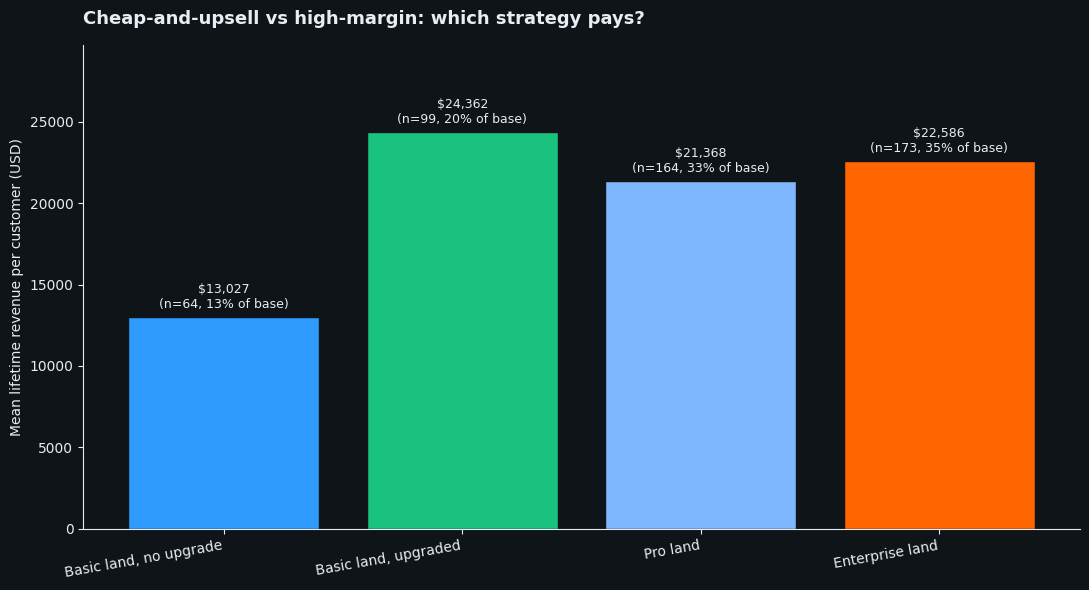

,strategy,n,share,mean_ltv,median_ltv,avg_tenure_mo,churn_rate
0,"Basic land, no upgrade",64,12.8%,"$13,027","$8,839",8.8,23.4%
1,"Basic land, upgraded",99,19.8%,"$24,362","$13,880",10.2,21.2%
2,Pro land,164,32.8%,"$21,368","$14,561",9.8,19.5%
3,Enterprise land,173,34.6%,"$22,586","$14,260",8.7,24.3%


In [3]:
basic = per_acc[per_acc['landing_plan']=='Basic']
strategies = {
    'Basic land, no upgrade': basic[~basic['upgraded']],
    'Basic land, upgraded':   basic[basic['upgraded']],
    'Pro land':               per_acc[per_acc['landing_plan']=='Pro'],
    'Enterprise land':        per_acc[per_acc['landing_plan']=='Enterprise'],
}
rows = []
for name, df in strategies.items():
    rows.append({
        'strategy': name, 'n': len(df), 'share': len(df)/len(per_acc),
        'mean_ltv': df['total_revenue'].mean(),
        'median_ltv': df['total_revenue'].median(),
        'avg_tenure_mo': df['tenure_months'].mean(),
        'churn_rate': df['churn_flag'].mean(),
    })
strat_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 6))
colors2 = [BRAND_BLUE, BRAND_GREEN, '#7FB7FF', BRAND_ORANGE]
bars = ax.bar(strat_df['strategy'], strat_df['mean_ltv'], color=colors2, edgecolor=BG_DARK)
for bar, v, n, s in zip(bars, strat_df['mean_ltv'], strat_df['n'], strat_df['share']):
    ax.text(bar.get_x() + bar.get_width()/2, v + max(strat_df['mean_ltv'])*0.015,
            f'${v:,.0f}\n(n={n}, {s:.0%} of base)', ha='center', va='bottom', color=FG_LIGHT, fontsize=9)
ax.set_ylabel('Mean lifetime revenue per customer (USD)')
ax.set_title('Cheap-and-upsell vs high-margin: which strategy pays?', loc='left', pad=15)
ax.set_ylim(0, max(strat_df['mean_ltv']) * 1.22)
plt.xticks(rotation=10, ha='right')
plt.tight_layout(); plt.show()

strat_df.assign(
    share=lambda x: (x['share']*100).round(1).astype(str)+'%',
    mean_ltv=lambda x: x['mean_ltv'].map('${:,.0f}'.format),
    median_ltv=lambda x: x['median_ltv'].map('${:,.0f}'.format),
    avg_tenure_mo=lambda x: x['avg_tenure_mo'].round(1),
    churn_rate=lambda x: (x['churn_rate']*100).round(1).astype(str)+'%',
)

**Read — the central finding of the study:**

| Strategy | Mean LTV | Share of base |
| --- | ---:| ---:|
| Basic land, **never** upgraded | **$13,027** | 13% |
| **Basic land, upgraded** | **$24,362** | 20% |
| Pro land | $21,368 | 33% |
| Enterprise land | $22,586 | 35% |

**The single most valuable customer segment is a Basic lander who upgrades** — they generate ~$1,800 more lifetime revenue than a direct-Enterprise customer, and ~$3,000 more than a Pro lander.

*Why?* Because they (a) stay around longer than enterprise customers (10.2 vs 8.7 months on average) and (b) churn at a lower rate (21% vs 24%). They self-selected upward — meaning they were genuinely growing — rather than being convinced to commit to high-tier from day one.

**The catch:** only **61%** of Basic landers upgrade. The other 39% are worth half as much.

This frames the operational priority: **the Basic→upgrade conversion rate is the highest-leverage metric in the business.** A 5-point lift (from 61% to 66%) on the 163 Basic landers in this dataset would have added ~$92,000 in lifetime revenue — without acquiring a single new customer.

## 4. Where do the high-LTV customers actually come from?

Channel × landing plan tells us which acquisition source produces which customer outcome.

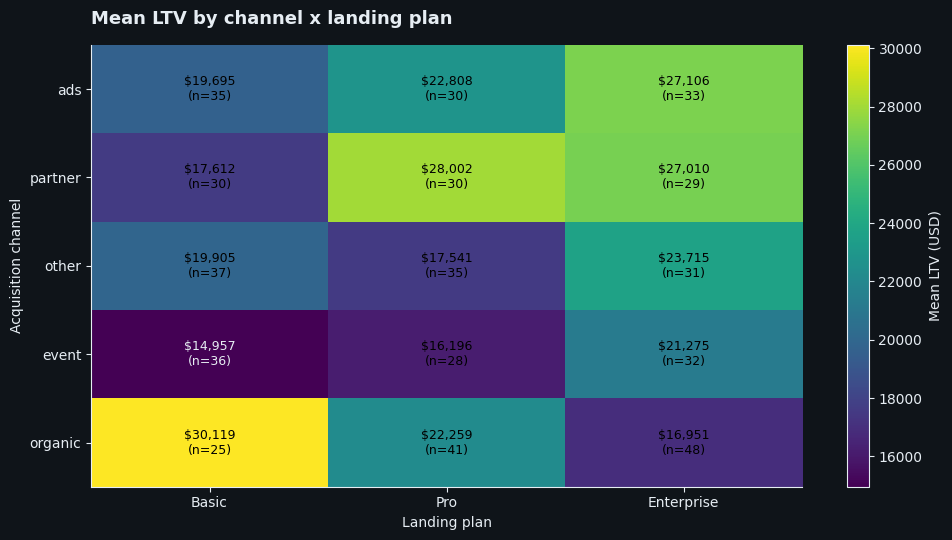

In [4]:
pivot = per_acc.pivot_table(index='referral_source', columns='landing_plan',
                            values='total_revenue', aggfunc='mean').reindex(columns=plan_order)
n_pivot = per_acc.pivot_table(index='referral_source', columns='landing_plan',
                               values='account_id', aggfunc='count').reindex(columns=plan_order)
pivot = pivot.sort_values('Enterprise', ascending=False)
n_pivot = n_pivot.loc[pivot.index]

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(plan_order))); ax.set_xticklabels(plan_order)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel('Landing plan'); ax.set_ylabel('Acquisition channel')
ax.set_title('Mean LTV by channel x landing plan', loc='left', pad=15)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.iat[i,j]; n = n_pivot.iat[i,j]
        if pd.notna(v):
            ax.text(j, i, f'${v:,.0f}\n(n={int(n)})', ha='center', va='center', fontsize=9,
                    color='black' if v > pivot.values.max()*0.5 else FG_LIGHT)
cbar = plt.colorbar(im, ax=ax, label='Mean LTV (USD)')
cbar.ax.yaxis.label.set_color(FG_LIGHT); cbar.ax.tick_params(colors=FG_LIGHT)
plt.tight_layout(); plt.show()

**Read the heatmap — three sharp observations:**

1. **Organic + Basic = $30,119** — the single most valuable cell on the grid. Customers who *find* the product and *start small* are the most productive of all. They have time to build conviction, and they upgrade aggressively.
2. **Partner + Pro = $28,002** — the second-best cell. Partner-sourced Pro landers convert at exceptional rates.
3. **Event channel is bottom-quartile across all plans.** Event + Basic ($14,957) and Event + Pro ($16,196) are the two worst cells. Combined with notebook 1's finding that event customers also churn at the highest rate (30%), this is a clear thumbs-down on event-led acquisition.

## 5. Annual vs monthly billing — the lock-in myth

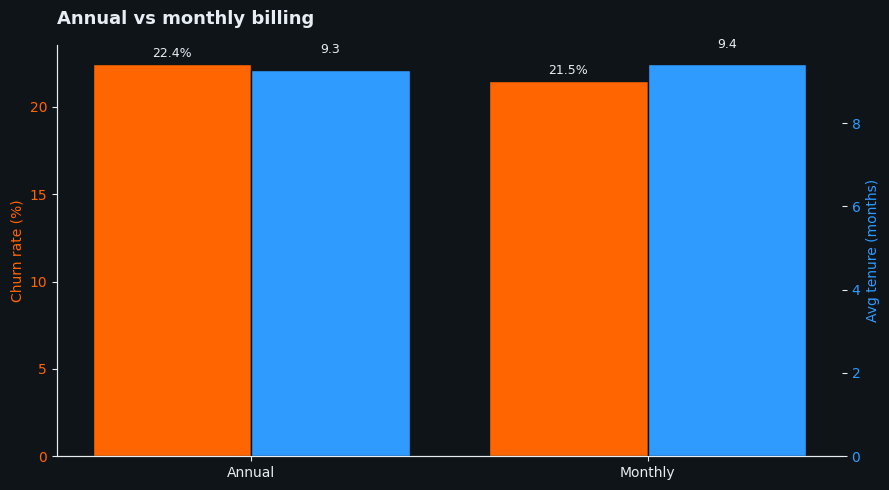

,n,mean_ltv,avg_tenure_mo,churn_rate
billing,,,,
annual,272,"$22,181",9.3,22.4%
monthly,228,"$20,281",9.4,21.5%


In [5]:
bill = per_acc.groupby('billing').agg(
    n=('account_id','count'),
    mean_ltv=('total_revenue','mean'),
    avg_tenure_mo=('tenure_months','mean'),
    churn_rate=('churn_flag','mean'),
)

fig, ax = plt.subplots(figsize=(9, 5))
cats = bill.index.tolist()
churn_pct = (bill['churn_rate']*100).values
tenure = bill['avg_tenure_mo'].values
x = np.arange(len(cats)); width = 0.4
b1 = ax.bar(x - width/2, churn_pct, width, color=BRAND_ORANGE, edgecolor=BG_DARK, label='Churn rate (%)')
ax2 = ax.twinx()
b2 = ax2.bar(x + width/2, tenure, width, color=BRAND_BLUE, edgecolor=BG_DARK, label='Avg tenure (months)')
ax.set_xticks(x); ax.set_xticklabels([c.capitalize() for c in cats])
ax.set_ylabel('Churn rate (%)', color=BRAND_ORANGE)
ax2.set_ylabel('Avg tenure (months)', color=BRAND_BLUE)
ax2.spines['top'].set_visible(False); ax.spines['top'].set_visible(False)
ax2.tick_params(axis='y', labelcolor=BRAND_BLUE); ax.tick_params(axis='y', labelcolor=BRAND_ORANGE)
for bar, v in zip(b1, churn_pct):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.4, f'{v:.1f}%', ha='center', color=FG_LIGHT, fontsize=9)
for bar, v in zip(b2, tenure):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.4, f'{v:.1f}', ha='center', color=FG_LIGHT, fontsize=9)
ax.set_title('Annual vs monthly billing', loc='left', pad=15)
plt.tight_layout(); plt.show()

bill.assign(
    mean_ltv=lambda x: x['mean_ltv'].map('${:,.0f}'.format),
    avg_tenure_mo=lambda x: x['avg_tenure_mo'].round(1),
    churn_rate=lambda x: (x['churn_rate']*100).round(1).astype(str)+'%',
)

**Read:** Annual billing customers churn at 22.0%; monthly at 21.0%. **Essentially no difference.** Average tenure is identical (9.3 vs 9.4 months). The LTV gap is ~9%, which is largely a pricing effect (annual plans are typically slightly discounted but recognised upfront).

This contradicts the SaaS conventional wisdom that *annual contracts = lower churn*. In this dataset, billing frequency does almost nothing for retention. Customers who want to leave appear to leave regardless of contract structure — annual contracts may just *defer* the cancellation to the renewal anniversary rather than prevent it.

**Practical implication:** the annual-billing discount RavenStack offers is not buying retention. It's buying upfront cash. That can still be a defensible trade — but it's a cash-flow argument, not a retention argument.

## 6. The bottom line: share of customers vs share of revenue

If every strategy generated revenue in proportion to its customer share, the green and blue bars below would be equal heights. Any imbalance is a structural over- or under-performance.

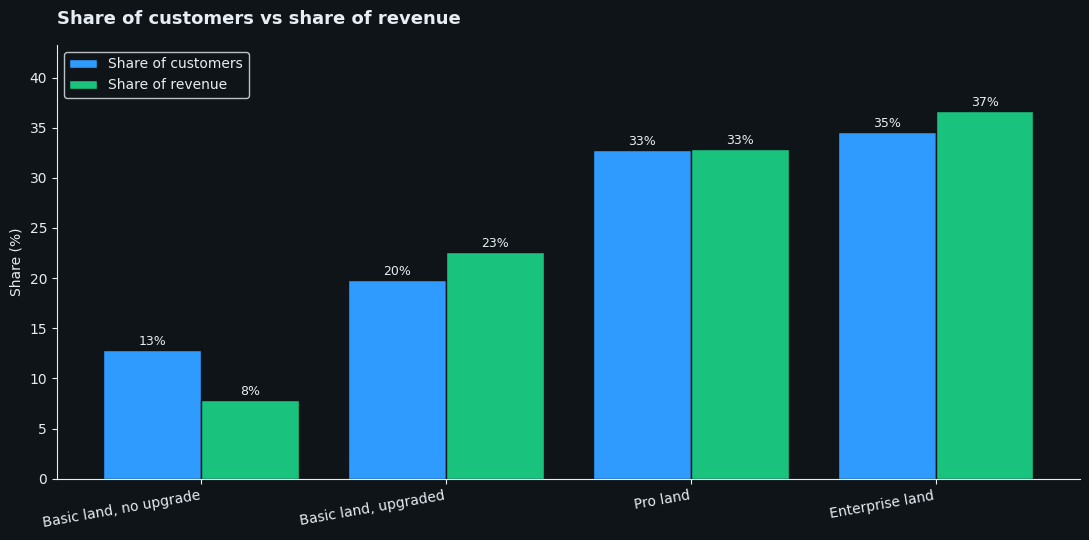

In [6]:
total_rev = per_acc['total_revenue'].sum()
contributions = []
for name, df in strategies.items():
    contributions.append({
        'strategy': name, 'n': len(df),
        'total_rev': df['total_revenue'].sum(),
        'share_of_revenue': df['total_revenue'].sum() / total_rev,
    })
contrib_df = pd.DataFrame(contributions)

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(contrib_df)); width = 0.4
share_cust = (contrib_df['n'] / contrib_df['n'].sum()) * 100
share_rev = contrib_df['share_of_revenue'] * 100
b1 = ax.bar(x - width/2, share_cust, width, color=BRAND_BLUE, label='Share of customers', edgecolor=BG_DARK)
b2 = ax.bar(x + width/2, share_rev, width, color=BRAND_GREEN, label='Share of revenue', edgecolor=BG_DARK)
for bar, v in zip(b1, share_cust):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.0f}%', ha='center', color=FG_LIGHT, fontsize=9)
for bar, v in zip(b2, share_rev):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.0f}%', ha='center', color=FG_LIGHT, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(contrib_df['strategy'], rotation=10, ha='right')
ax.set_ylabel('Share (%)'); ax.set_title('Share of customers vs share of revenue', loc='left', pad=15)
ax.set_ylim(0, max(max(share_cust), max(share_rev)) * 1.18)
ax.legend(facecolor=BG_DARK, edgecolor=FG_LIGHT, labelcolor=FG_LIGHT, loc='upper left')
plt.tight_layout(); plt.show()

**Read:**

- **Basic-only:** 13% of customers, just 8% of revenue. Under-performs.
- **Basic-upgraded:** 20% of customers, 23% of revenue. Over-performs.
- **Pro land:** 33% of customers, 33% of revenue. Average.
- **Enterprise land:** 35% of customers, 37% of revenue. Slightly over-performs.

Enterprise-land is only marginally more revenue-productive than its share. The "premium customer pulls weight" hypothesis isn't really supported — premium customers pay more per month, but they also churn faster and stay shorter, which cancels most of the advantage.

---
## The pricing strategy recommendation

**Cheap-and-upsell wins — when the upsell happens.**

1. **Lead with Basic, optimise for upgrade conversion.** The successful Basic-upgrader is the most valuable customer segment ($24,362 LTV) — more valuable than direct-Enterprise sales. The strategic priority is not which plan to push at the top of the funnel; it is the **Basic→Pro/Enterprise conversion rate**, currently 61% and the highest-leverage metric in the business.
2. **Cut event-led acquisition.** Events deliver the lowest-LTV customers ($17,424) at the highest churn rate (30%). Every dollar of events budget would be better spent on partner channel ($24,177 LTV, 14.6% churn) or organic ($21,748 LTV, 17.5% churn).
3. **Stop subsidising annual billing for retention.** Annual contracts do not materially reduce churn (22.0% vs 21.0%). If RavenStack offers an annual discount, it should justify it on cash-flow grounds, not retention grounds — and consider tightening the discount.
4. **The price-tier gap doesn't matter as much as it looks.** Despite a 10× MRR difference between Basic and Enterprise, LTV varies only 13% by landing plan. Expansion mechanics — not entry price — are what drive lifetime value.

## What this means for a real business reading this study

If you operate a multi-tier subscription product, this analysis suggests three operational moves with high expected return:

- Build a **structured upgrade prompt** at the 90-day mark for Basic landers (when retention is high but upgrade behaviour begins).
- **Reallocate sales/marketing mix** away from events and toward partner programs.
- **Audit your annual-billing discount.** If it's larger than ~5-7% it may be giving away margin without buying retention.

These are testable hypotheses, not certainties — they're derived from a single 500-customer dataset over 24 months. But the structural patterns (LTV convergence, channel quality gap, billing-frequency neutrality) are robust enough to be worth running an experiment on.